# Allotaxonographs of U.S. presidential speech across eras

This example compares the vocabulary of U.S. presidential speeches across
25-year eras with **keyflux** — keyness (keywords + lockwords), rank-turbulence
divergence (RTD), and the allotaxonograph.

The data are compact frequency tables under `examples/data/`, built from the
public-domain [Miller Center](https://data.millercenter.org/) presidential
speech corpus (lemmatised, lowercased, punctuation stripped) bundled with
[chronowords](https://github.com/crow-intelligence/chronowords). Each table is
`type<TAB>count`, trimmed to count ≥ 2, and is loaded with `keyflux.load_counts`.

In [1]:
from collections import Counter
from pathlib import Path

from keyflux import (
    Keyness,
    RankedList,
    allotaxonograph,
    allotaxonometer,
    load_counts,
    rtd,
)

try:
    HERE = Path(__file__).resolve().parent
except NameError:  # running as a notebook — no __file__
    HERE = Path("examples") if Path("examples/data").exists() else Path(".")
DATA = HERE / "data"
GALLERY = HERE / "gallery"
GALLERY.mkdir(exist_ok=True)

# Lemmatisation and transcription leave clitic fragments (ve, ll, re) and stage
# markers ([applause], speaker labels). They are real tokens but pure noise, so
# we drop them from the counts up front — this keeps genuine function words (the,
# of, be, which), which legitimately populate the lockword diagonal.
_NOISE = {
    "ve", "ll", "re", "s", "d", "m", "t", "s1", "s2", "p1", "p2",
    "applause", "laughter", "crosstalk", "inaudible", "span", "class",
    "nbsp", "amp", "quot", "don", "didn", "doesn", "isn", "aren", "wasn",
    "won", "wouldn", "couldn", "shouldn", "hasn", "haven", "uh", "um",
}


def clean(counter):
    """Drop single-character tokens and known clitic/transcript noise."""
    return Counter({t: c for t, c in counter.items() if len(t) > 1 and t not in _NOISE})


PERIODS = ["1825-1849", "1900-1924", "1950-1974", "2000-2024"]
counts = {p: clean(load_counts(DATA / f"speeches_{p}.tsv")) for p in PERIODS}
for p in PERIODS:
    print(f"{p}: {sum(counts[p].values()):>8,} tokens, {len(counts[p]):>6,} types")


def content_words(rows, n=12):
    """Top keyword surface forms for the printed lists."""
    return [row.type for row in rows[:n]]


def show(fig):
    """Embed a Figure as a PNG output when run in a notebook; no-op in a script."""
    try:
        from io import BytesIO

        from IPython.display import Image, display
    except ImportError:
        return
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(data=buf.getvalue()))

1825-1849:  440,954 tokens,  6,111 types
1900-1924:  460,194 tokens,  7,875 types
1950-1974:  555,210 tokens,  7,582 types
2000-2024:  627,316 tokens,  8,389 types


## The comparison helper

For a focus era vs. a reference era it prints the positive keywords (typical of
the focus era), the negative keywords (typical of the reference era), and a few
lockwords (stable across both), then renders the allotaxonograph.

In [2]:
def compare(focus_period, reference_period, *, alpha=1 / 3, save_as=None):
    """Keyness + RTD + allotaxonograph for two eras; returns the Figure."""
    focus, reference = counts[focus_period], counts[reference_period]
    k = Keyness(
        focus, reference,
        min_focus_freq=10, min_reference_freq=10,
        reference_id=reference_period,
    )
    kw = k.keywords()
    print(f"\n=== {focus_period}  vs  {reference_period} ===")
    print(f"typical of {focus_period}:   {content_words(kw.positive())}")
    print(f"typical of {reference_period}:   {content_words(kw.negative())}")
    print(f"lockwords (stable):   {content_words(k.lockwords(min_freq_both=50))}")

    r_focus = RankedList.from_counts(focus, label=focus_period)
    r_reference = RankedList.from_counts(reference, label=reference_period)
    result = rtd(r_focus, r_reference, alpha=alpha)
    print(f"rank-turbulence divergence (alpha={alpha:.3g}): {result.divergence:.4f}")

    fig = allotaxonograph(
        r_focus, r_reference, alpha=alpha,
        labels=(focus_period, reference_period),
    )
    if save_as:
        fig.savefig(GALLERY / save_as, dpi=130, bbox_inches="tight")
        print(f"saved gallery/{save_as}")
    return fig

## 1. The nineteenth century vs. the twenty-first

The most dramatic shift: formal 19th-century governmental prose
(*appropriation, intercourse, specie*) against modern televised address
(*job, help, tonight*). Function words fill the lockword diagonal.


=== 2000-2024  vs  1825-1849 ===
typical of 2000-2024:   ['job', 'help', 'today', 'talk', 'tonight', 'woman', 'iraq', 'worker', 'big', 'terrorist', 'afghanistan', 'billion']
typical of 1825-1849:   ['appropriation', 'intercourse', 'indians', 'heretofore', 'favorable', 'specie', 'receipt', 'disposition', 'entertain', 'satisfactory', 'furnish', 'proceeding']
lockwords (stable):   ['have', 'it', 'country', 'these', 'great', 'those', 'two', 'before', 'mean', 'force', 'continue', 'hope']
rank-turbulence divergence (alpha=0.333): 0.4573


saved gallery/era_2000-2024_vs_1825-1849.png


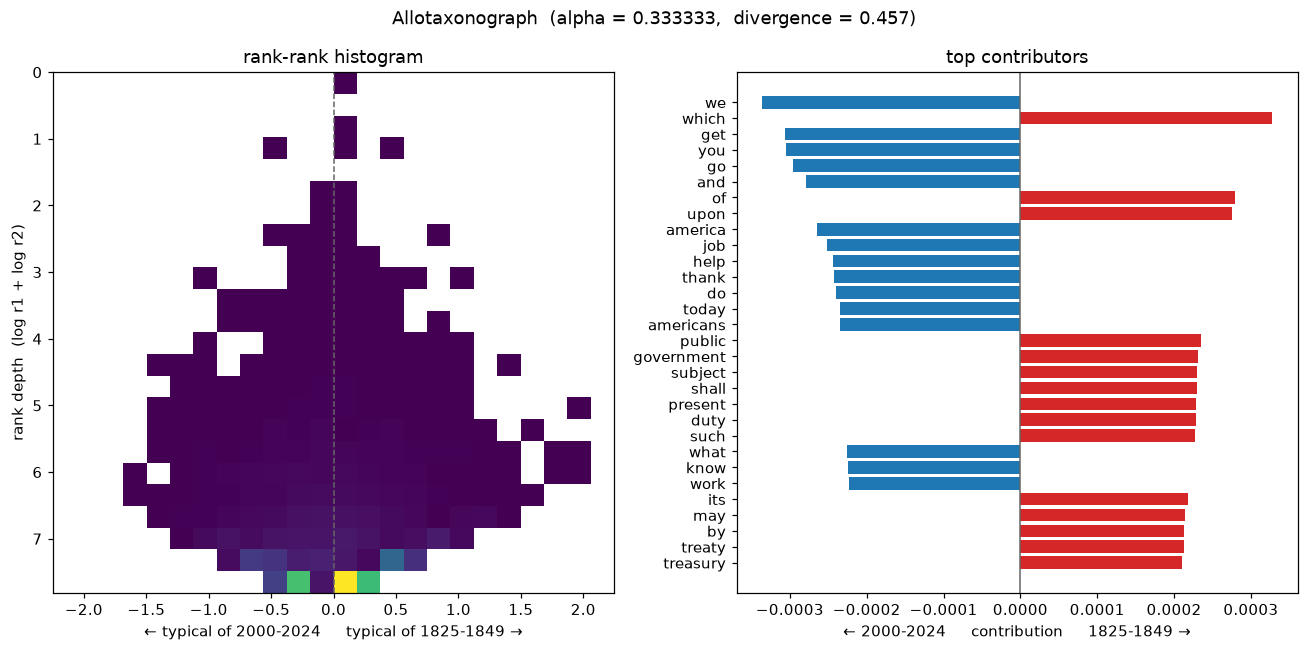

In [3]:
fig1 = compare("2000-2024", "1825-1849", save_as="era_2000-2024_vs_1825-1849.png")
show(fig1)

## 2. Progressive era vs. the Cold War


=== 1950-1974  vs  1900-1924 ===
typical of 1950-1974:   ['vietnam', 'tonight', 'soviet', 'kennedy', 'communist', 'viet', 'nam', 'nuclear', 'vietnamese', 'nixon', 'communists', 'eisenhower']
typical of 1900-1924:   ['39', 'railway', 'isthmus', 'colon', 'philippine', 'imperial', 'porto', 'hague', 'reclamation', 'belligerent', 'banking', 'exposition']
lockwords (stable):   ['to', 'for', 'their', 'there', 'other', 'any', 'united', 'so', 'country', 'good', 'need', 'give']
rank-turbulence divergence (alpha=0.333): 0.3284


saved gallery/era_1950-1974_vs_1900-1924.png


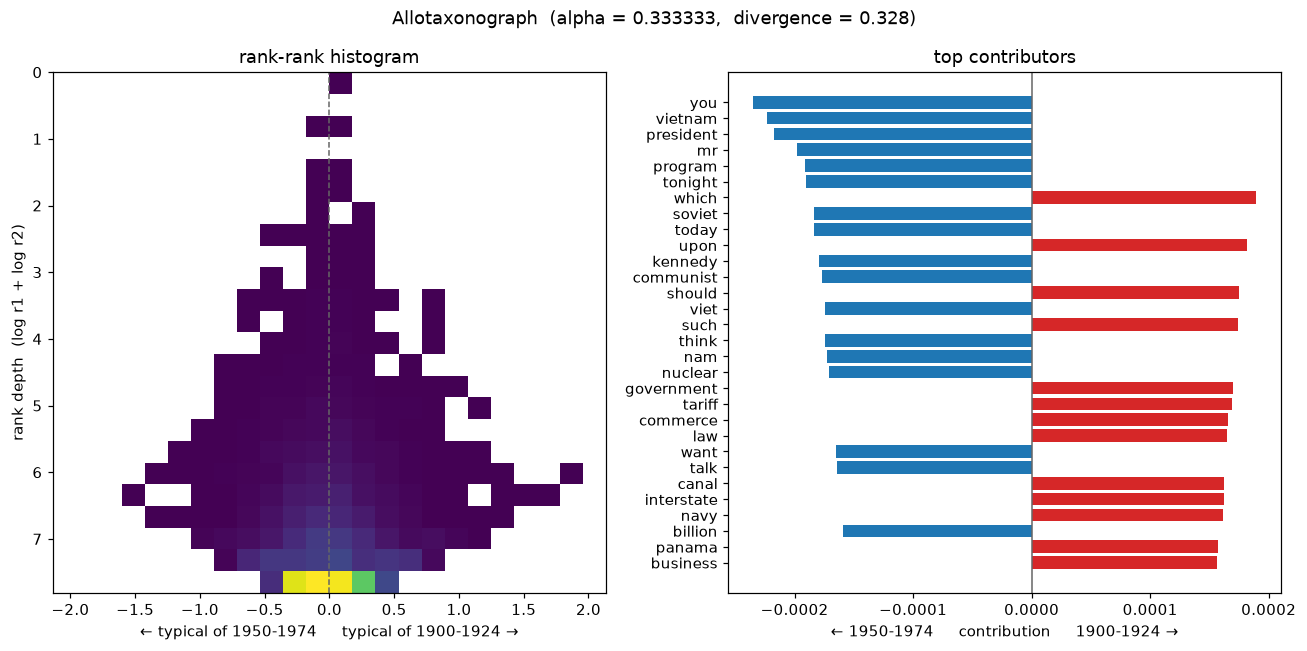

In [4]:
fig2 = compare("1950-1974", "1900-1924", save_as="era_1950-1974_vs_1900-1924.png")
show(fig2)

## 3. The Cold War vs. the modern era — a subtler shift


=== 2000-2024  vs  1950-1974 ===
typical of 2000-2024:   ['afghanistan', 'trump', 'iraqi', 'okay', 'virus', 'qaeda', 'ukraine', 'guy', '39', 'yeah', 'biden', 'iraq']
typical of 1950-1974:   ['viet', 'nam', 'communists', 'negro', 'khrushchev', 'watergate', 'appropriation', '1960', 'laos', '1954', 'mrs', 'mcnamara']
lockwords (stable):   ['to', 'that', 'our', 'with', 'can', 'at', 'there', 'if', 'now', 'time', 'my', 'new']
rank-turbulence divergence (alpha=0.333): 0.3110


saved gallery/era_2000-2024_vs_1950-1974.png


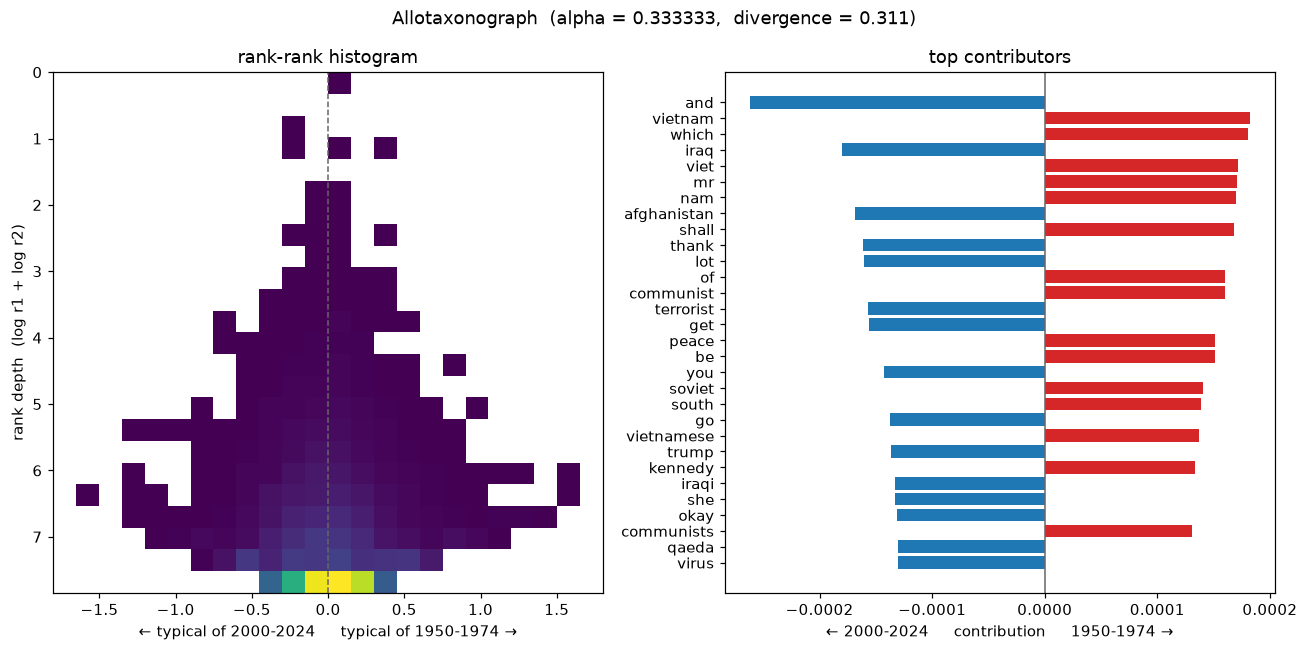

In [5]:
fig3 = compare("2000-2024", "1950-1974", save_as="era_2000-2024_vs_1950-1974.png")
show(fig3)

## How alpha reframes the map

`alpha` tunes what the divergence emphasises. Small `alpha` surfaces churn
among rare, low-rank words; large `alpha` surfaces shifts among the common,
high-rank words. Here is the 19thC↔21stC pair at three settings.


=== 2000-2024  vs  1825-1849 ===
typical of 2000-2024:   ['job', 'help', 'today', 'talk', 'tonight', 'woman', 'iraq', 'worker', 'big', 'terrorist', 'afghanistan', 'billion']
typical of 1825-1849:   ['appropriation', 'intercourse', 'indians', 'heretofore', 'favorable', 'specie', 'receipt', 'disposition', 'entertain', 'satisfactory', 'furnish', 'proceeding']
lockwords (stable):   ['have', 'it', 'country', 'these', 'great', 'those', 'two', 'before', 'mean', 'force', 'continue', 'hope']
rank-turbulence divergence (alpha=0): 0.3922


saved gallery/alpha_sweep_0.png


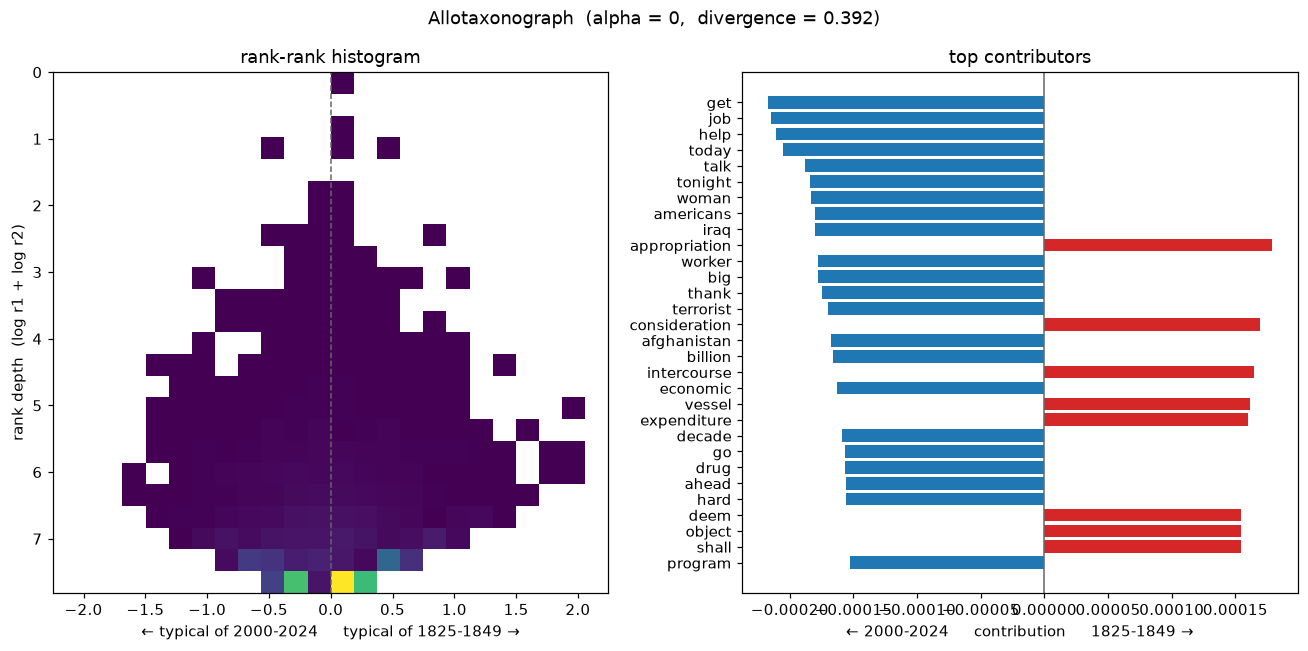


=== 2000-2024  vs  1825-1849 ===
typical of 2000-2024:   ['job', 'help', 'today', 'talk', 'tonight', 'woman', 'iraq', 'worker', 'big', 'terrorist', 'afghanistan', 'billion']
typical of 1825-1849:   ['appropriation', 'intercourse', 'indians', 'heretofore', 'favorable', 'specie', 'receipt', 'disposition', 'entertain', 'satisfactory', 'furnish', 'proceeding']
lockwords (stable):   ['have', 'it', 'country', 'these', 'great', 'those', 'two', 'before', 'mean', 'force', 'continue', 'hope']
rank-turbulence divergence (alpha=0.333): 0.4573


saved gallery/alpha_sweep_0.33.png


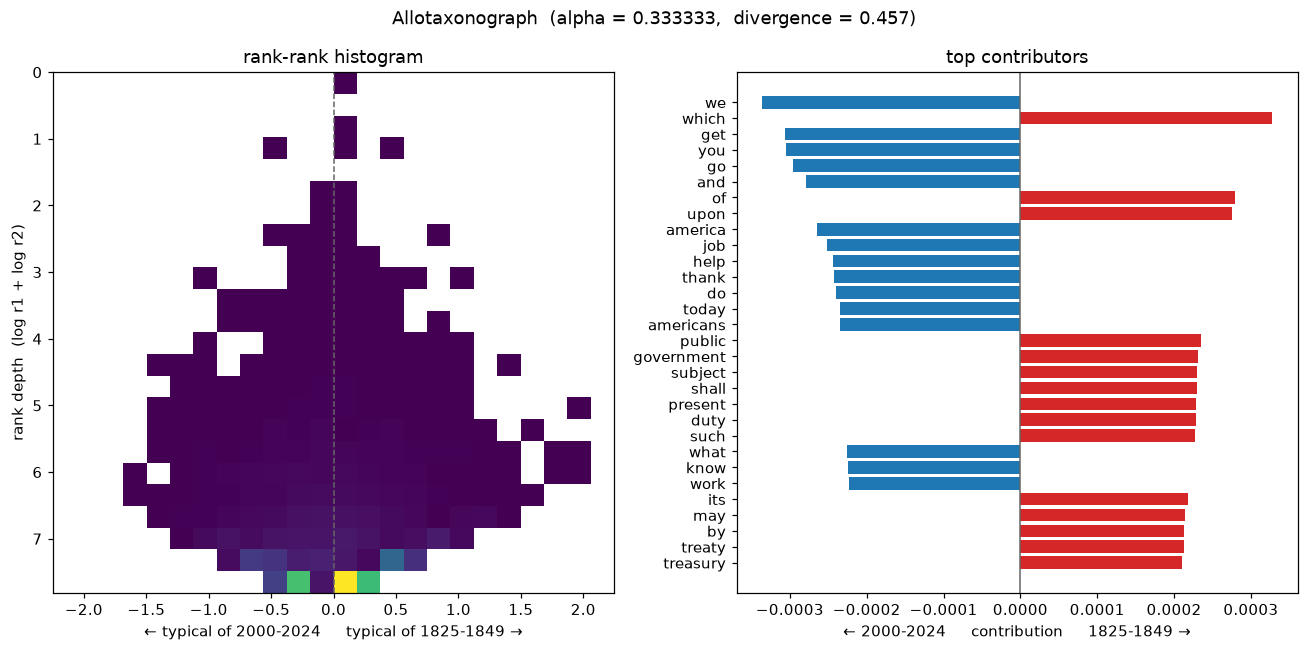


=== 2000-2024  vs  1825-1849 ===
typical of 2000-2024:   ['job', 'help', 'today', 'talk', 'tonight', 'woman', 'iraq', 'worker', 'big', 'terrorist', 'afghanistan', 'billion']
typical of 1825-1849:   ['appropriation', 'intercourse', 'indians', 'heretofore', 'favorable', 'specie', 'receipt', 'disposition', 'entertain', 'satisfactory', 'furnish', 'proceeding']
lockwords (stable):   ['have', 'it', 'country', 'these', 'great', 'those', 'two', 'before', 'mean', 'force', 'continue', 'hope']
rank-turbulence divergence (alpha=1): 0.5366


saved gallery/alpha_sweep_1.png


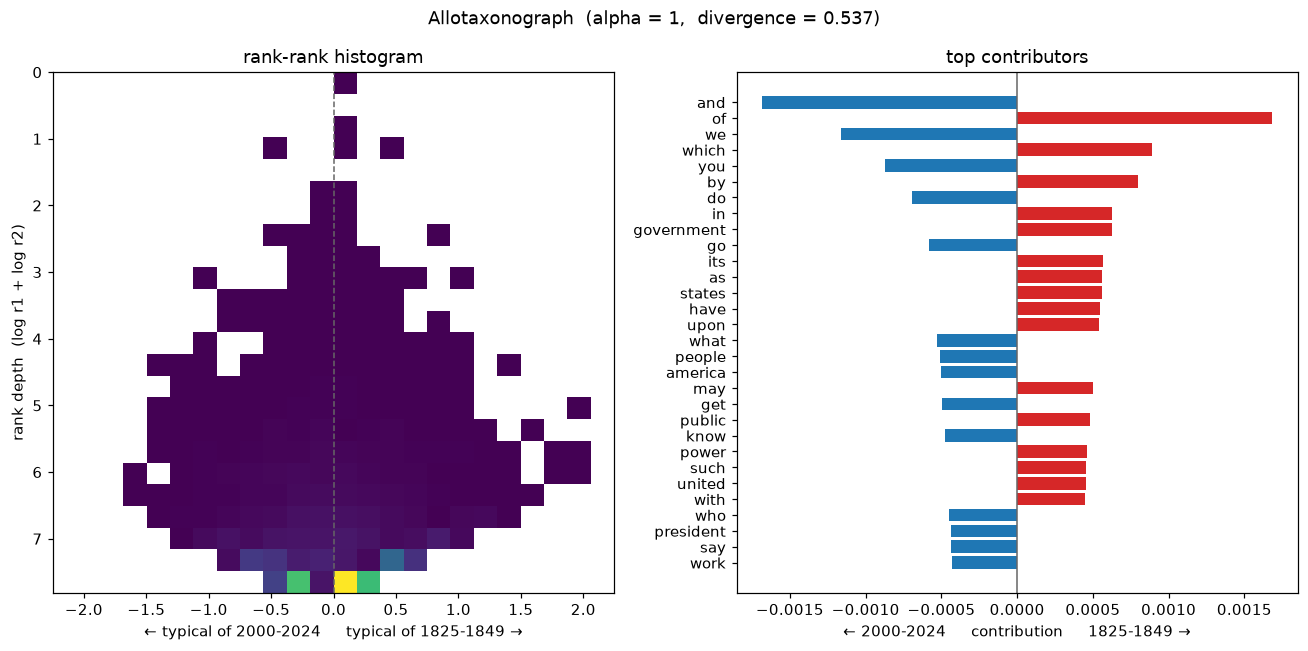

In [6]:
for a, tag in [(0.0, "0"), (1 / 3, "0.33"), (1.0, "1")]:
    fig = compare("2000-2024", "1825-1849", alpha=a,
                  save_as=f"alpha_sweep_{tag}.png")
    show(fig)

## The diamond allotaxonograph (`allotaxonometer`)

The same comparisons in the canonical Dodds (2020) diamond: a rotated-square
rank-rank histogram with iso-divergence contours and a wordshift list. Shared
function words sit on the vertical centre near the top; era-specific and
exclusive words fan out to the edges.

In [7]:
def diamond(focus_period, reference_period, *, alpha=1 / 3, save_as=None):
    """Render the diamond allotaxonograph for two eras; returns the Figure."""
    r_focus = RankedList.from_counts(counts[focus_period], label=focus_period)
    r_reference = RankedList.from_counts(
        counts[reference_period], label=reference_period
    )
    fig = allotaxonometer(r_focus, r_reference, alpha=alpha)
    if save_as:
        fig.savefig(GALLERY / save_as, dpi=130, bbox_inches="tight")
        print(f"saved gallery/{save_as}")
    return fig

saved gallery/diamond_2000-2024_vs_1825-1849.png


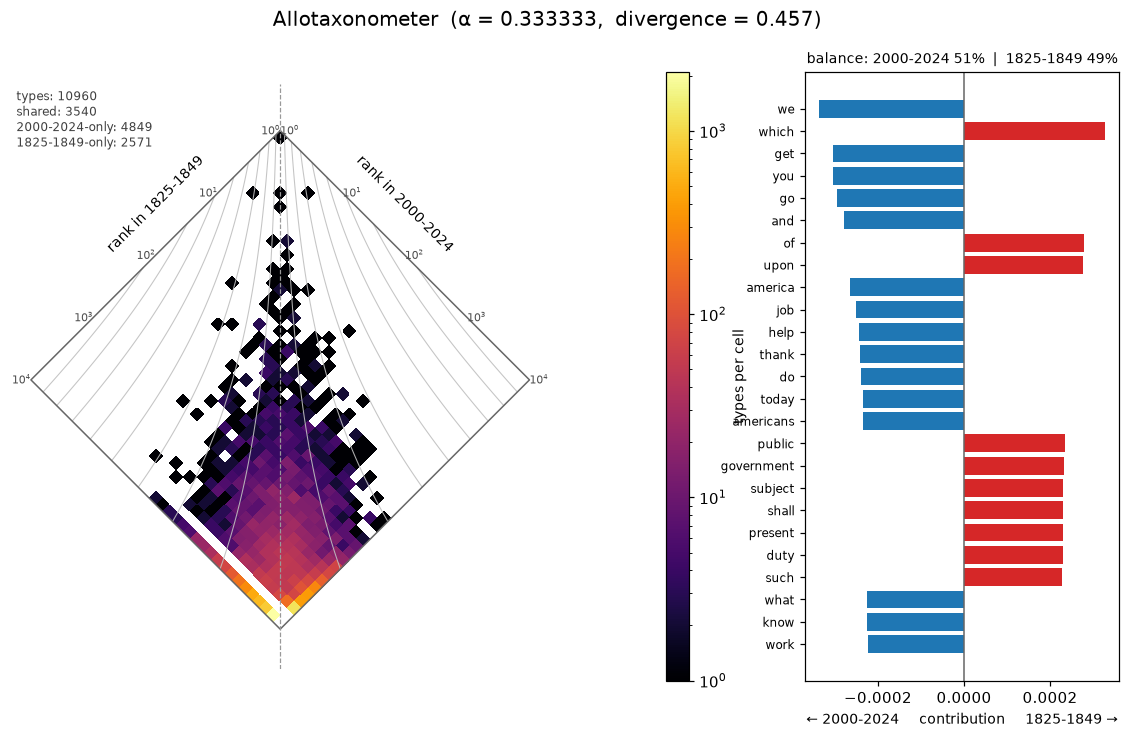

In [8]:
show(diamond("2000-2024", "1825-1849", save_as="diamond_2000-2024_vs_1825-1849.png"))

saved gallery/diamond_2000-2024_vs_1950-1974.png


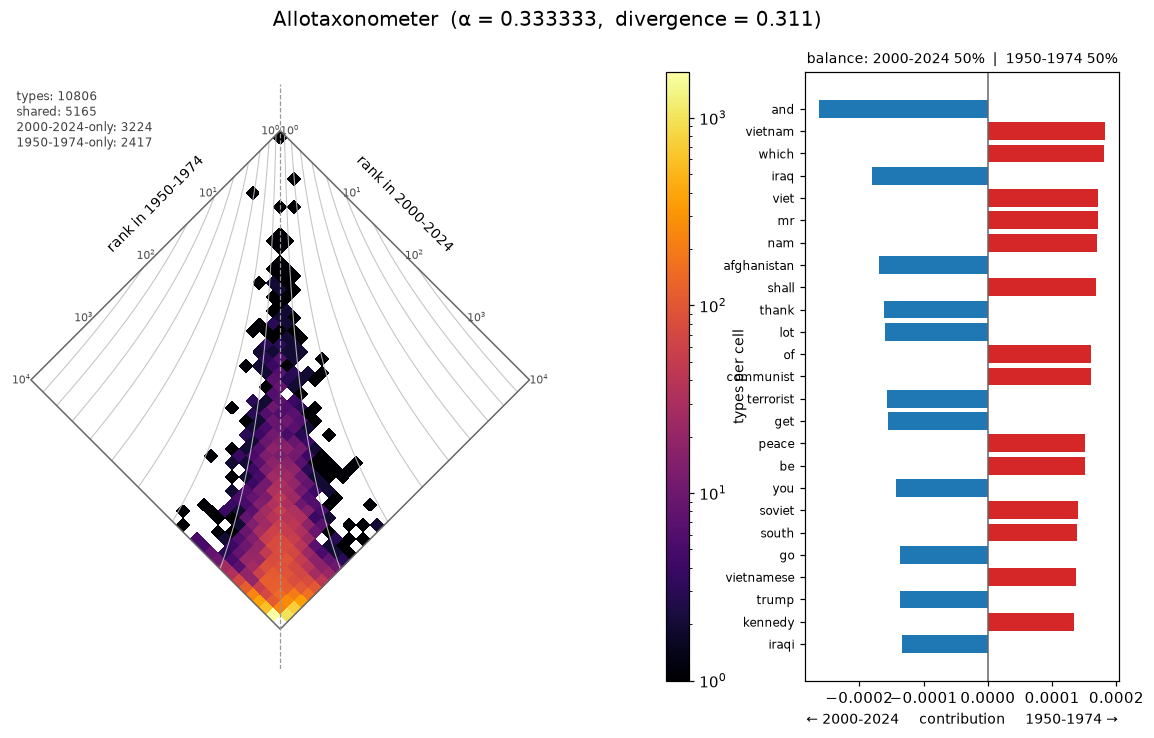

In [9]:
show(diamond("2000-2024", "1950-1974", save_as="diamond_2000-2024_vs_1950-1974.png"))

## Frequent words vs. keywords — two rankings of one corpus

`allotaxonometer` compares *any* two rankings. Here we rank the 2000–2024
corpus two ways — by raw frequency and by keyness (log-likelihood vs the
1825–1849 reference, via `RankedList.from_scores`) — and diamond them against
each other. Function words top the frequency ranking but vanish from the
keyness ranking; content words leap up. It's the same vocabulary, reordered.

saved gallery/diamond_frequency_vs_keyness.png


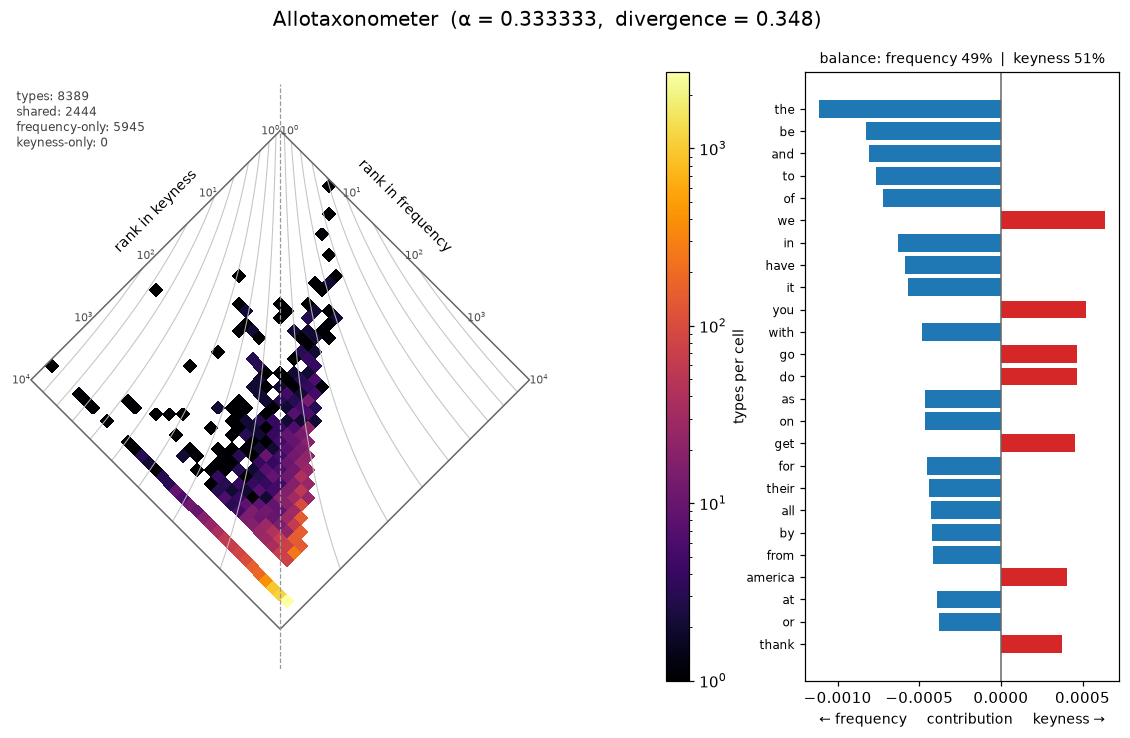

In [10]:
freq_rank = RankedList.from_counts(counts["2000-2024"], label="frequency")
_k = Keyness(counts["2000-2024"], counts["1825-1849"],
             min_focus_freq=10, min_reference_freq=10)
key_scores = {r.type: r.statistic for r in _k.table() if r.direction == "positive"}
key_rank = RankedList.from_scores(key_scores, label="keyness")
fig_fk = allotaxonometer(freq_rank, key_rank, alpha=1 / 3)
fig_fk.savefig(
    GALLERY / "diamond_frequency_vs_keyness.png", dpi=130, bbox_inches="tight"
)
print("saved gallery/diamond_frequency_vs_keyness.png")
show(fig_fk)

## Keyness vs. keyness — which words are distinctive of each era

Keyness always needs a reference. To compare *eras* on equal footing we give
each era the **same** reference: the rest of the presidential corpus (all other
eras combined). For each era we rank its over-represented words by keyness
(log-likelihood, `RankedList.from_scores`) — its "distinctive vocabulary" — and
diamond two eras' keyness rankings against each other. Words distinctive of
*both* compared eras (versus the tradition) sit near the top centre; words
distinctive of only one era fan out to its side; the divergence measures how
differently the two eras stand out.

In [11]:
def era_keyness_ranking(period, *, min_freq=10):
    """Rank a period's over-represented words by keyness vs the rest of the corpus."""
    rest = Counter()
    for other, c in counts.items():
        if other != period:
            rest.update(c)
    k = Keyness(
        counts[period], rest, min_focus_freq=min_freq, min_reference_freq=min_freq
    )
    scores = {r.type: r.statistic for r in k.table() if r.direction == "positive"}
    return RankedList.from_scores(scores, label=period)


def keyness_diamond(period_a, period_b, *, alpha=1 / 3, save_as=None):
    """Diamond two eras' keyness rankings (each vs the rest of the corpus)."""
    fig = allotaxonometer(
        era_keyness_ranking(period_a), era_keyness_ranking(period_b), alpha=alpha
    )
    if save_as:
        fig.savefig(GALLERY / save_as, dpi=130, bbox_inches="tight")
        print(f"saved gallery/{save_as}")
    return fig

saved gallery/keyness_1950-1974_vs_2000-2024.png


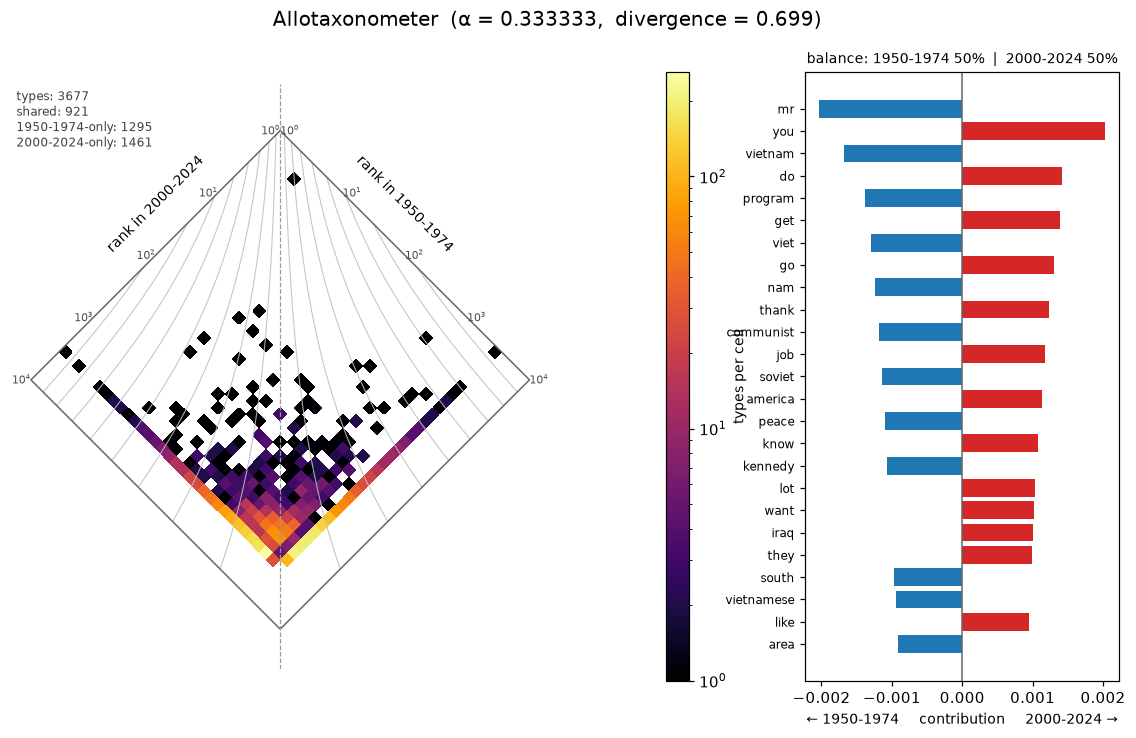

In [12]:
show(keyness_diamond("1950-1974", "2000-2024",
                     save_as="keyness_1950-1974_vs_2000-2024.png"))

saved gallery/keyness_1825-1849_vs_2000-2024.png


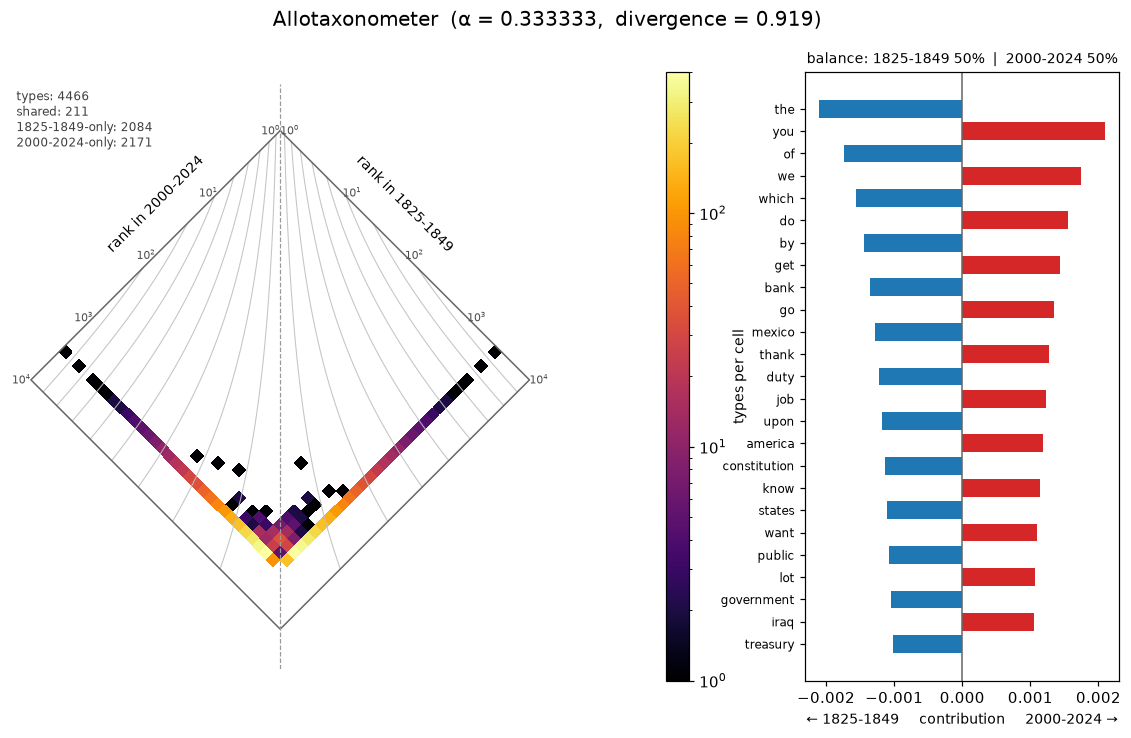

In [13]:
show(keyness_diamond("1825-1849", "2000-2024",
                     save_as="keyness_1825-1849_vs_2000-2024.png"))